<a href="https://colab.research.google.com/github/Raj-Shekhar-Bakshi/AQI-Prediction_Project/blob/main/AirQualityPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Welcome to Air Pollution Predection Model")
print("Enter the pollutant level to ")

Welcome to Air Pollution Predection Model
Enter the pollutant level to 


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def train_air_quality_model(file_path):
    # 1. Load data
    print("Loading data...")
    df = pd.read_csv(file_path)

    # 2. Target Variable: Drop rows where the target 'AQI' is missing
    df = df.dropna(subset=['AQI']).copy()

    # 3. Feature Engineering
    # Extract Year and Month from the Date column for seasonal trends
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    # Drop Date (already parsed) and AQI_Bucket (to prevent target leakage)
    df = df.drop(['Date', 'AQI_Bucket'], axis=1)

    # Define features (X) and target (y)
    X = df.drop('AQI', axis=1)
    y = df['AQI']

    # 4. Identify column types for pipelines
    categorical_cols = ['City']
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # 5. Define Preprocessing Steps
    # Numeric preprocessing: Impute missing values with median, then scale
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical preprocessing: Impute missing, then One-Hot Encode
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Bundle preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])

    # 6. Define the Model
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    # Create full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # 7. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
     # 8. Train the model
    print("Training Random Forest Regressor...")
    pipeline.fit(X_train, y_train)

    # 9. Evaluate Performance
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print("\n--- Model Performance ---")
    print(f"R² Score : {r2*100:.4f} (Explains ~{r2*100:.2f}% of the variance)")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")

    return pipeline

# Run the model
if __name__ == "__main__":
    best_model = train_air_quality_model('/content/drive/MyDrive/Ai_Training/PollutionOfCity_dayWise.csv')

Loading data...
Training Random Forest Regressor...

--- Model Performance ---
R² Score : 91.1061 (Explains ~91.11% of the variance)
RMSE     : 40.3555
MAE      : 20.4268


EDA

      AIR QUALITY DATASET EDA            

✅ Dataset loaded successfully!

--- 1. DATASET SHAPE & INFO ---
Total Rows: 29531
Total Columns: 16

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


--- 2. MISSING VALUES (%) ---
Xylene        61.32 %
PM10          37.72 %
NH3           34.97 %
Toluene       27.23 %
Benzene       19.04 %
AQI           15.85 %
AQI_Bucket    15.85 %
PM2.5         15.57 %
NOx           14.17 %
O3            13.62 %
SO2           13.05 %
NO2           12.14 %
NO            12.13 %
CO             6.

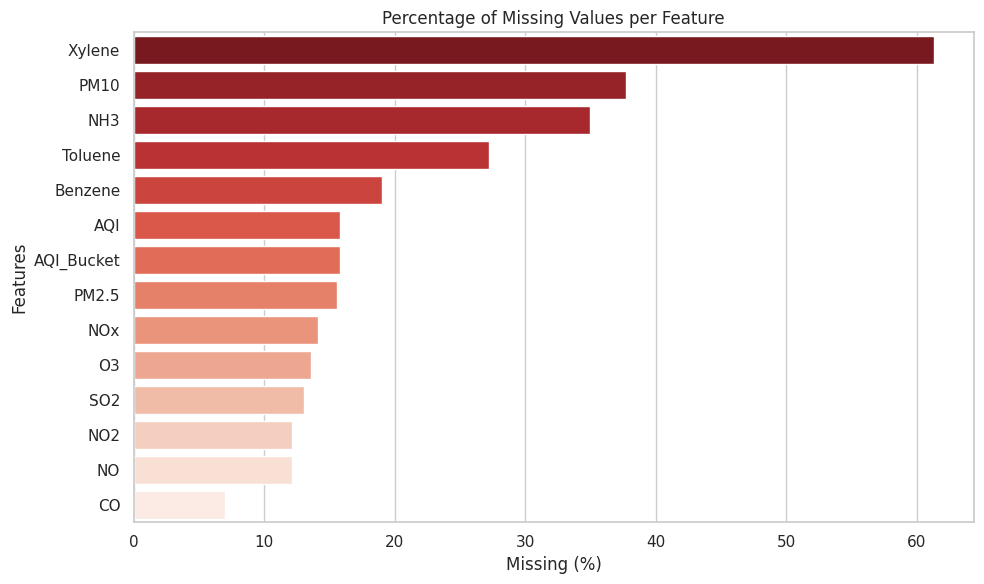

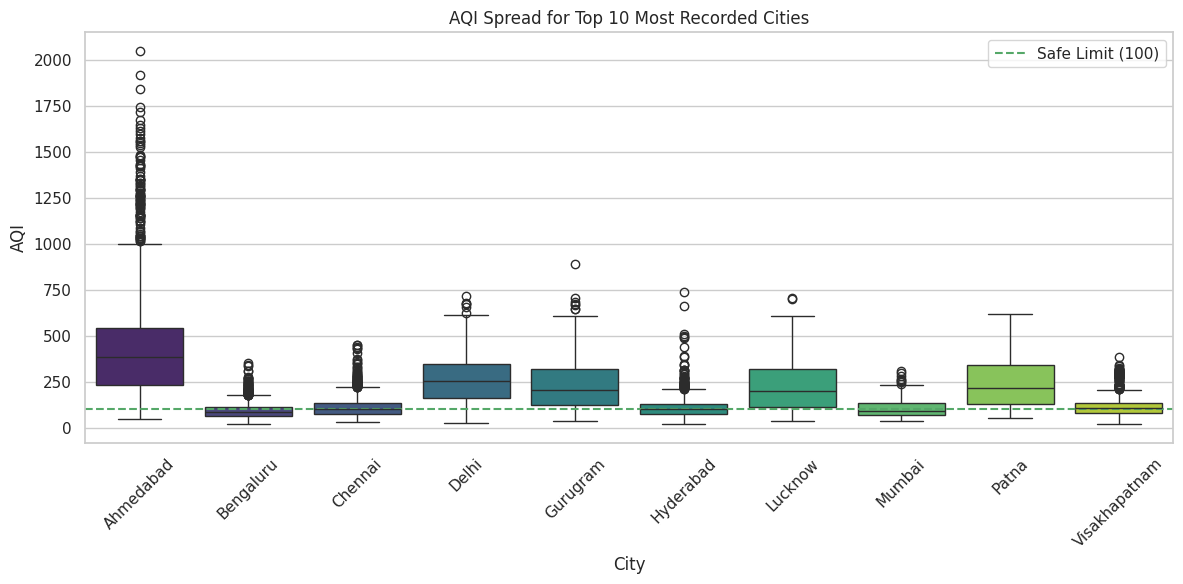

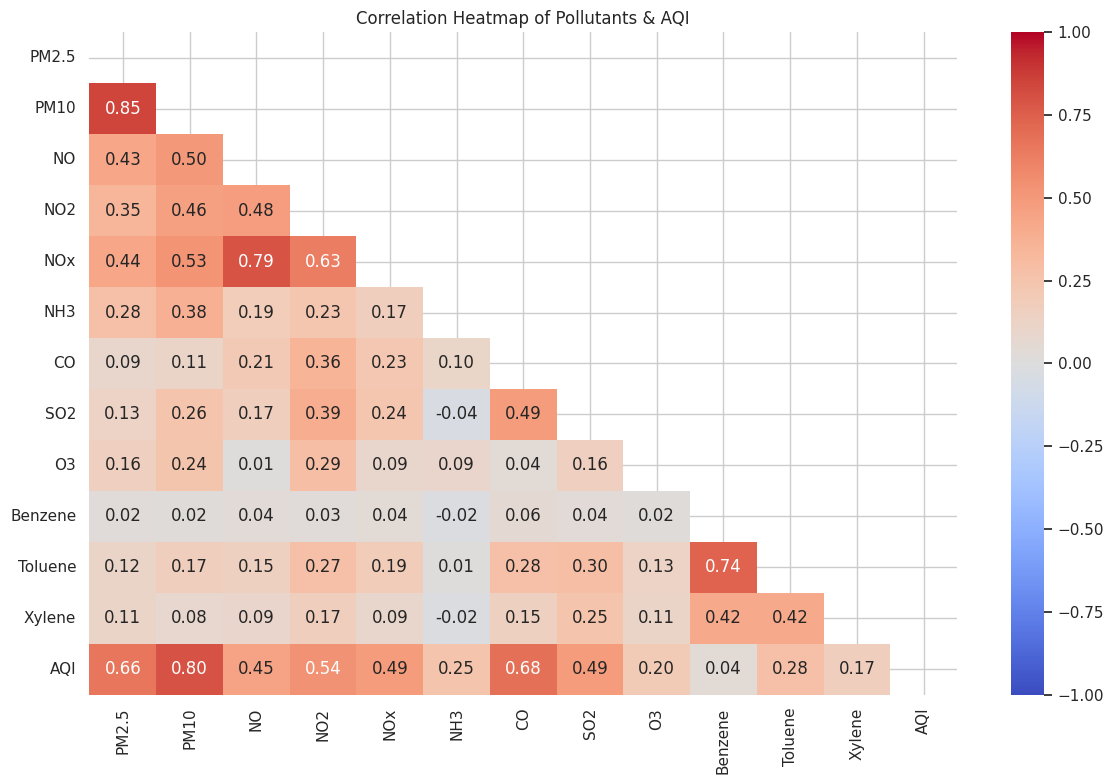

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def perform_eda(file_path):
    print("=========================================")
    print("      AIR QUALITY DATASET EDA            ")
    print("=========================================\n")

    # 1. Load Data
    try:
        df = pd.read_csv(file_path)
        print("✅ Dataset loaded successfully!\n")
    except FileNotFoundError:
        print(f"❌ Error: Could not find {file_path}")
        return

    # 2. Dataset Overview
    print("--- 1. DATASET SHAPE & INFO ---")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    print("\nColumns:", df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)
    print("\n")

    # 3. Missing Values Analysis
    print("--- 2. MISSING VALUES (%) ---")
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
    print(missing_pct.round(2).astype(str) + " %")
    print("\n")

    # 4. Target Variable (AQI) Distribution
    print("--- 3. AQI BUCKET DISTRIBUTION ---")
    if 'AQI_Bucket' in df.columns:
        aqi_dist = df['AQI_Bucket'].value_counts(normalize=True) * 100
        print(aqi_dist.round(2).astype(str) + " %")
    print("\n")

    # 5. Correlation with AQI
    print("--- 4. TOP POLLUTANTS CORRELATED WITH AQI ---")
    numeric_cols = df.select_dtypes(include=[np.number])
    correlations = numeric_cols.corr()['AQI'].sort_values(ascending=False).drop('AQI')
    print(correlations.head(5).round(4))
    print("\n")

    # 6. City-wise Analysis
    print("--- 5. CITY-WISE POLLUTION (Average AQI) ---")
    city_aqi = df.dropna(subset=['AQI']).groupby('City')['AQI'].mean()

    top_5_polluted = city_aqi.sort_values(ascending=False).head(5)
    top_5_cleanest = city_aqi.sort_values(ascending=True).head(5)

    print("Top 5 Most Polluted Cities:")
    print(top_5_polluted.round(2))
    print("\nTop 5 Least Polluted Cities:")
    print(top_5_cleanest.round(2))
    print("\n")

    # ==========================================
    # VISUALIZATIONS
    # ==========================================
    print("Generating visualizations... Close each window to view the next one.")

    # Set visualization style
    sns.set_theme(style="whitegrid")

    # Plot 1: Missing Values Bar Chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")
    plt.title("Percentage of Missing Values per Feature")
    plt.xlabel("Missing (%)")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    # Plot 2: AQI Distribution Boxplot by City (Top 10 most recorded cities)
    top_10_cities = df['City'].value_counts().head(10).index
    df_top10 = df[df['City'].isin(top_10_cities)].dropna(subset=['AQI'])

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='City', y='AQI', data=df_top10, palette="viridis")
    plt.title("AQI Spread for Top 10 Most Recorded Cities")
    plt.xticks(rotation=45)
    plt.axhline(y=100, color='g', linestyle='--', label='Safe Limit (100)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 3: Correlation Heatmap
    plt.figure(figsize=(12, 8))
    corr_matrix = numeric_cols.corr()
    # Mask the upper triangle for cleaner visualization
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Pollutants & AQI")
    plt.tight_layout()
    plt.show()

# Run the EDA
if __name__ == "__main__":
    perform_eda("/content/drive/MyDrive/Ai_Training/PollutionOfCity_dayWise.csv")